# Random Forest with Entropy — Augmented Dataset (500 per class)

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
sns.set_palette('Blues')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Blues(np.linspace(0.3,0.9,8)))
import warnings; warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('../../augmented_data.csv')
print(f"Shape:{df.shape}\nClass distribution:\n{df['diagnosis'].value_counts()}")

Shape:(1000, 31)
Class distribution:
diagnosis
1    500
0    500
Name: count, dtype: int64


In [3]:
X=df.drop('diagnosis',axis=1);y=df['diagnosis']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train);X_test=scaler.transform(X_test)

In [4]:
m=RandomForestClassifier(criterion='entropy',random_state=42)
m.fit(X_train,y_train)
y_pred=m.predict(X_test);y_proba=m.predict_proba(X_test)[:,1]
print("RF Entropy trained.")

RF Entropy trained.


In [5]:
acc=accuracy_score(y_test,y_pred);prec=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred);f1=f1_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred);tn,fp,fn,tp=cm.ravel()
spec=tn/(tn+fp);auc=roc_auc_score(y_test,y_proba)
print(f"Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f} Spec:{spec:.4f} AUC:{auc:.4f}\nCM:\n{cm}")

Acc:0.9750 Prec:1.0000 Rec:0.9500 F1:0.9744 Spec:1.0000 AUC:0.9962
CM:
[[100   0]
 [  5  95]]


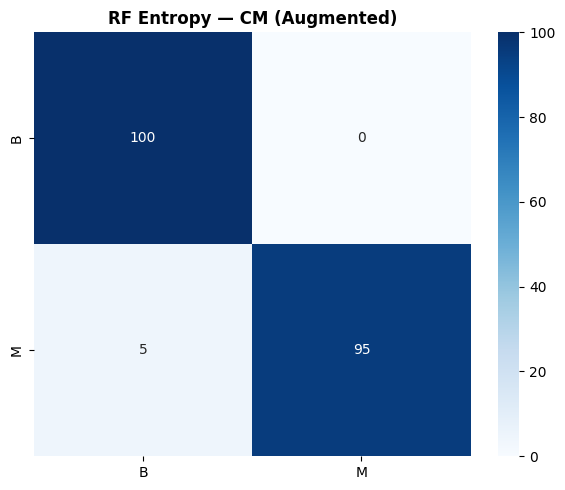

In [6]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['B','M'],yticklabels=['B','M'])
plt.title('RF Entropy — CM (Augmented)',fontweight='bold');plt.tight_layout();plt.show()

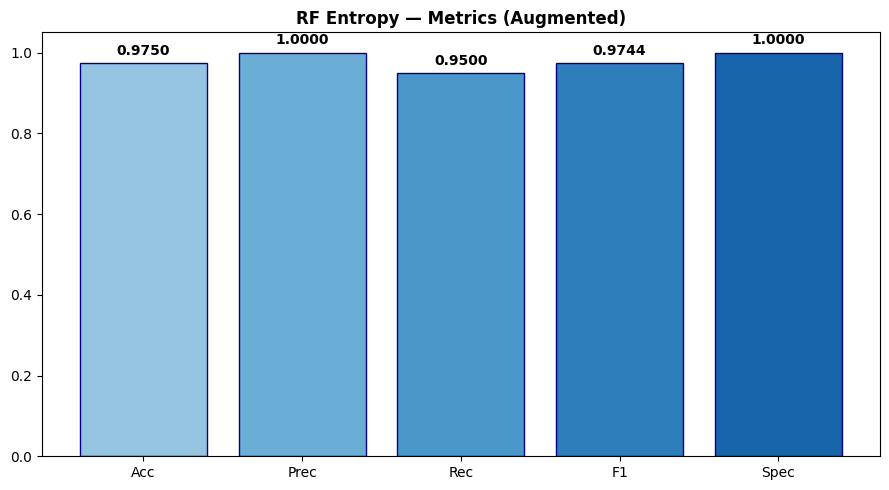

In [7]:
n=['Acc','Prec','Rec','F1','Spec'];v=[acc,prec,rec,f1,spec];c=plt.cm.Blues([0.4,0.5,0.6,0.7,0.8])
plt.figure(figsize=(9,5));bars=plt.bar(n,v,color=c,edgecolor='darkblue')
plt.ylim(0,1.05);plt.title('RF Entropy — Metrics (Augmented)',fontweight='bold')
for b,v in zip(bars,v):plt.text(b.get_x()+b.get_width()/2,b.get_height()+0.02,f'{v:.4f}',ha='center',fontweight='bold')
plt.tight_layout();plt.show()

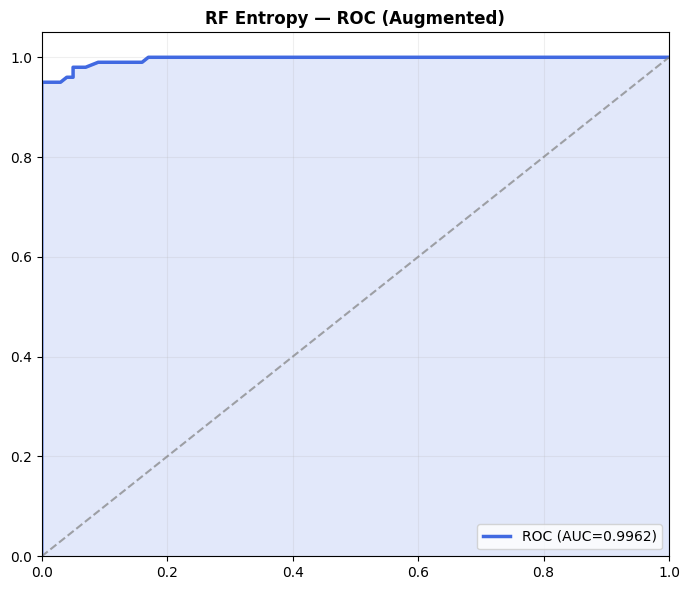

In [8]:
fpr,tpr,_=roc_curve(y_test,y_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,'royalblue',lw=2.5,label=f'ROC (AUC={auc:.4f})')
plt.fill_between(fpr,tpr,alpha=0.15,color='royalblue')
plt.plot([0,1],[0,1],'gray',ls='--',alpha=0.7)
plt.xlim(0,1);plt.ylim(0,1.05);plt.title('RF Entropy — ROC (Augmented)',fontweight='bold')
plt.legend();plt.grid(alpha=0.2);plt.tight_layout();plt.show()